**Hyperdimensional Computing:** You have a playroom full of toys. As long as there are only a few toys, it does not matter if your playroom does not have structure to it. You can still find your toys easily and all is good. But what if you have 10,000 toys in your playroom? Or a million toys? Then, you need a way to organize the toys. You could just take all of the toys and put them on the shelf with no rules (one dimension), but this would still not be very organized. If you wanted to find an individual toy, you would struggle. So, you begin to catalogue the different attributes of the toys and you put these attributes into a database of tables. You could have tables for color, play type, configuration, number of players, type of game, type of hero, types of weapons, literally anything could be a table. You could have thousands and thousands of tables. One day, a scientist invents a magic shelf, it allows you to actually store your toys in these tables. You simply put your toy into a drawer, and it is magically whisked to every table it needs to be in inside of the storage container. You can then query the storage container for 'only red toys' and your new toy would be in the query if it is a red toy. It would also exist on every other shelf though that it matches attributes for as well. And all of these shelves would fit inside of your playroom.

Each "toy" is represented as a random high-dimensional vector. We'll use NumPy for simplicity. The vector space (e.g., 10,000 dimensions) ensures that every toy and attribute has its own unique representation.

In [ ]:
import numpy as np

# Function to create a random high-dimensional vector
def create_random_vector(dimensions=10000):
    return np.random.choice([-1, 1], size=dimensions)  # High-dimensional binary vector

We create random high-dimensional vectors for each attribute (e.g., "red," "action figure," "hero"). These act as the magic labels or "shelves."

In [ ]:
# Define attributes as random vectors
attributes = {
    "red": create_random_vector(),
    "blue": create_random_vector(),
    "action_figure": create_random_vector(),
    "hero": create_random_vector(),
    "vehicle": create_random_vector()
}

A toy (e.g., "red hero action figure") is represented by binding and bundling its attributes. We use element-wise multiplication (binding) to create unique representations and addition (bundling) to combine attributes.

In [ ]:
# Function to encode a toy by combining attributes
def encode_toy(*attributes_to_combine):
    encoded_vector = np.ones_like(attributes_to_combine[0])  # Start with neutral vector
    for attr in attributes_to_combine:
        encoded_vector *= attr  # Element-wise multiplication (binding)
    return encoded_vector

For example:

In [ ]:
red_hero_action_figure = encode_toy(
    attributes["red"], attributes["hero"], attributes["action_figure"]
)

We store toys in a database (list of vectors). To find toys matching a query (e.g., "red"), we compute the cosine similarity between the query vector and all stored vectors.

In [ ]:
# Cosine similarity function
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Store toys in a database
toy_database = [red_hero_action_figure]

# Query the database
def query_database(query_vector, database, threshold=0.5):
    results = []
    for idx, toy in enumerate(database):
        similarity = cosine_similarity(query_vector, toy)
        if similarity > threshold:  # Threshold to determine a match
            results.append(idx)  # Store matching toy's index
    return results

Querying for "red toys":

In [ ]:
red_query = attributes["red"]
matches = query_database(red_query, toy_database)

print(f"Matching toy indices: {matches}")

Matching toy indices: []


Showcasing what this looks like with a real world code example:

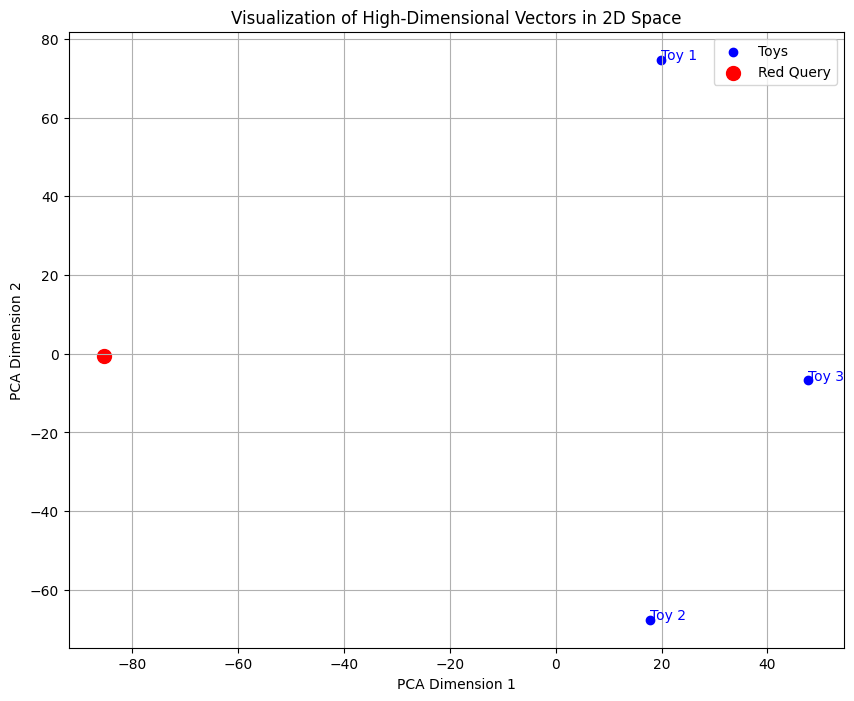

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Create random high-dimensional vectors
def create_random_vector(dimensions=10000):
    return np.random.choice([-1, 1], size=dimensions)

# Cosine similarity function
def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# Encode a toy by combining attributes
def encode_toy(*attributes_to_combine):
    encoded_vector = np.ones_like(attributes_to_combine[0])  # Start with a neutral vector
    for attr in attributes_to_combine:
        encoded_vector *= attr  # Element-wise multiplication (binding)
    return encoded_vector

# Query the database for similar vectors
def query_database(query_vector, database, threshold=0.5):
    results = []
    for idx, toy in enumerate(database):
        similarity = cosine_similarity(query_vector, toy)
        if similarity > threshold:  # Matches exceed threshold
            results.append((idx, similarity))
    return results

# Step 2: Create attributes as random high-dimensional vectors
dimensions = 10000
attributes = {
    "red": create_random_vector(dimensions),
    "blue": create_random_vector(dimensions),
    "action_figure": create_random_vector(dimensions),
    "hero": create_random_vector(dimensions),
    "vehicle": create_random_vector(dimensions)
}

# Step 3: Encode some toys
red_hero_action_figure = encode_toy(attributes["red"], attributes["hero"], attributes["action_figure"])
blue_vehicle = encode_toy(attributes["blue"], attributes["vehicle"])
red_vehicle = encode_toy(attributes["red"], attributes["vehicle"])

# Store toys in a database
toy_database = [red_hero_action_figure, blue_vehicle, red_vehicle]

# Step 4: Query for red toys
red_query = attributes["red"]
matches = query_database(red_query, toy_database, threshold=0.5)

# Step 5: Visualize the high-dimensional space using PCA
# Reduce dimensionality for visualization
pca = PCA(n_components=2)
data_matrix = np.vstack([red_query] + toy_database)  # Combine query and database
reduced_data = pca.fit_transform(data_matrix)

# Plot the reduced vectors
plt.figure(figsize=(10, 8))
plt.scatter(reduced_data[1:, 0], reduced_data[1:, 1], color='blue', label='Toys')
plt.scatter(reduced_data[0, 0], reduced_data[0, 1], color='red', label='Red Query', s=100)
for i, (x, y) in enumerate(reduced_data[1:], start=1):
    plt.text(x, y, f"Toy {i}", fontsize=10, color="blue")

plt.title("Visualization of High-Dimensional Vectors in 2D Space")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

# Print query results
for idx, similarity in matches:
    print(f"Toy {idx + 1} matches the query with similarity: {similarity:.2f}")